In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !pip install konlpy
# !pip install mecab-python
# !bash <(curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh) #한국어 형태소 분석기

In [ ]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

In [ ]:
# !pip install scikit-learn
# !pip install koreanize-matplotlib

In [ ]:
import json
import re
from konlpy.tag import Okt
from collections import Counter
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
from wordcloud import WordCloud

In [ ]:
import pandas as pd

path = '/content/drive/MyDrive/최종프로젝트/data/Lotion_dataset_clean.csv'

df = pd.read_csv(path, index_col=False)
raw = df.copy()

In [ ]:
df.head(3)

,Unnamed: 0,name,brand,price,sale_price,picture,url,volume,skin_type,ingredient,review
0,0,AHC 온리 포맨 로션 150ml,AHC,"25,000","14,000",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,150ml,모든 피부용,"정제수, 글리세린, 디메치콘, 나이아신아마이드, 사이클로펜타실록산, 세틸알코올, 카...",아빠께서 로션을 열심히 찾고 계시길래 같이 가서 테스트 해보고 구매한 제품입니다 아...
1,1,BRTC 파워 옴므 올인원 솔루션 200ml,비알티씨,"28,000","25,600",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,200ml,모든 피부 타입,"정제수, 부틸렌글라이콜, 글리세린, 에탄올, 나이아신아마이드, 비스-피이지-18메칠...",디자인도 멋있고 고급스러워 남편 선물용으로 딱이겠더라고요 스킨 로션 에센스까지 한번...
2,5,[NEW/리뉴얼] 에스트라 아토베리어365 로션 150ml,에스트라,"33,000","33,000",https://image.oliveyoung.co.kr/uploads/images/...,https://www.oliveyoung.co.kr/store/goods/getGo...,150ml,모든 피부용,"정제수, 부틸렌글라이콜, 글리세린, 다이메티콘, 스쿠알란, 펜타에리스리틸테트라아이소...",너무 기름지지 않고 보습력 좋게 가볍게 바를수있는 로션이에요 호불호없이 사용 가능 ...


전처리

In [ ]:
from konlpy.tag import Okt
from sklearn.feature_extraction.text import CountVectorizer
import re

In [ ]:
df['review']

0     아빠께서 로션을 열심히 찾고 계시길래 같이 가서 테스트 해보고 구매한 제품입니다 아...
1     디자인도 멋있고 고급스러워 남편 선물용으로 딱이겠더라고요 스킨 로션 에센스까지 한번...
2     너무 기름지지 않고 보습력 좋게 가볍게 바를수있는 로션이에요 호불호없이 사용 가능 ...
3     진정이 되는지도 잘 모르겠고 그냥 무난한데 세검이 유명한 라인이라 로션 시도한건데 ...
4     남자친구 주려고 샀어요 남자친구가 만족하면서 쓰는 거 같아요 ㅋㅋ 저도 써봤는데 좋...
                            ...                        
62    촉촉하고 무난하게 쓰기 좋아요 무향에 가까워서 남자도 쓰기 좋습니다 이거만한게 없습...
63    수부지 각질부각에 트러블까지 있으신분들 진짜 강추입니다 왜냐면 제 피부가 그랬거든요...
64    기본 밀크보다 더 촉촉한데 부드럽게 흡수됩니다 그리고 번들거리지도 않습니다 부드럽고...
65    여향갔다가 하도 유명해서 사봤는데 너무 순하고 보습력도 좋아서 또 재구매해서 쓰고있...
66    엄마가 한율 에센스도 사용중이고 만족해하세요 에멀젼 역시 만족해하시네요 재구매 예정...
Name: review, Length: 67, dtype: object

In [ ]:
corpus = "".join(df['review'].tolist())
corpus

'아빠께서 로션을 열심히 찾고 계시길래 같이 가서 테스트 해보고 구매한 제품입니다 아빠께서 만족하고 계신다고 합니다 아빠가 사용하시는 제품인데 올인원이라 편하기도 하고 순해서 사용하기 좋다고 하세요 아빠께서 계속 쓰시는 로션이에요 다음에 또 재구매 할게요  아빠 선물로 사드렸는데 좋아하셨어요 향이 무난해서 좋은 것 같아요 부드럽게 사용할 수 있어 좋네요 향기도 은은해서 강하지 않아 좋아요 아빠께 사 드렸는데 그냥 딱 무난하게 잘 사용하시는 것 같아요 스킨이랑 같이 구매해서 쓰는 중이에요 물론 남자친구가 잘 사용중이에요 아빠 사줳는데 괜찮다고 하시네요 하나만 바르샤도 되서 편하대요 남성분들 관리가 어려운데 그냥 이거 하나만 바르면 돼서 되게좋아더라고요 선물용으로 샀는데 받으신 분이 좋아하시네요 다음번에도 재 구매 할꺼같아여 촉촉하고 좋아요 다 쓰면 다음에 또 구입하려구요 만족합니다 아버지가 전에 사용하셨던 제품이에요 화장품에서 나는 향이 무척 좋았던 기억이 있어서 구입했어요 무난하게 사용하셨던 기억이 있어요 지금 사용하는 것도 괜찮은 제품이지만 너무 저가인 것 같아서 이 제품으로 바꿨어요 행사가에 저렴하게 구입햇어요 남편이 촉촉하고 향도 은은하고 좋다고 하네요 선물용으로 토너로션 같이 구매했어요 만족해서 재구매했습니다 피부에 부담없고 자극 없다고 하시네요 보습도 괜찮아서 아버지께서 괜찮다고 하세요 나이대 있는 남성분에게 잘 어울리는 올인원 로션이에요 제형도 무겁지 않아 잘 쓰고 계세요 사용감이 좋고 향도 세지 않아서 좋아여 세트로 구매했더니 좋네여 선물로 뭐할까 고민하다가 지인이 추천해줘서 구매했는데 향도 좋고 촉촉함이 오래가요 아빠 쓰시라고 구매했는데 잘 사용하고 계시네요 재구매 의사 있어요 친구 선물로 사줬어요 무난하게 쓰기 좋은거 같아요 좀 더 써봐야해요 우리아빠 로션 향기나는게 좋다길래 매장에 있는거 여러개 맡아봤는데 이게 젤 좋네요 오래 사용하지 않았지만 피부에 자극없이 순해서 아주 만족합니당  남자들이 사용하기 무난한 제품인것 같습니다별다른 화장품 사

불용어 리스트 가져오기

In [ ]:
path = '/content/drive/MyDrive/최종프로젝트/data/stopword_list.xlsx'

stop_words = pd.read_excel(path)


In [ ]:
stop_words = stop_words['stopword'].tolist()
print(stop_words)

['가까스로', '가량', '가령', '가민', '가민커넥트', '가슴', '가슴살', '각', '가지', '각각', '각자', '각종', '갖고말하자면', '같다', '같이', '개발', '개발자', '개별로', '개월', '개의치않고', '거기', '거니와', '거바', '거의', '건데', '건지', '걸까요', '걸로', '것', '것과 같이', '것들', '게다가', '게요', '게우다', '겨우', '견지에서', '결과에 이르다', '결국', '결론을 낼 수 있다', '겸사겸사', '경우', '계속', '고감', '고로', '곧', '고려하면', '고민', '고생', '고요', '공동으로', '과', '과연', '관계가 있다', '관련', '관련이 있다', '관리자', '관한', '관하여', '관해서는', '구', '구글플레이스토어', '구체적으로', '구토하다', '귀차 니즘', '귀차니즘', '그', '그거', '그건', '그걸', '그걸로', '그것', '그게', '그곳', '그날', '그동안', '그들', '그때', '그래', '그래도', '그래서', '그램', '그러나', '그러니', '그러니까', '그러면', '그러므로', '그러한즉', '그럼', '그렇게 함으로써', '그렇지', '그렇지만', '그리고', '그리하여', '그에 따르는', '그위에', '그인', '그저', '그중에서', '근거로', '근거하여', '금요일', '기능', '기대여', '기모', '기점으로', '기준으로', '기타', '기프', '까닭으로', '까악', '까지 미치다', '까지도', '꽈당', '끙끙', '끼익', '나', '나름', '나머지는', '나세', '나용', '나이키', '나중', '난리', '남들', '남자', '남짓', '내게', '내요', '내일', '너', '너희', '너희들', '네', '넷', '네요', '넷째', '년', '논하지 않다', '누가', '누가 알겠는가', '누구', '누군가', '눔', '느낌', '니다', '니스', '니

In [ ]:
#추가할 불용어 여기에 입력
add_stopwords = '피부, 좋아요, 올리브영, 로션, 스킨, 좋습니다, '

for word in add_stopwords.split(','):
    stop_words.append(word)

In [ ]:
#stop_words안에 '피부' 단어 찾기
for word in stop_words:
  if '올리브영' in word:
    print(word)

 올리브영


Konlpy.tag Okt

### 단어 추출
효과, 성분, 성별&나이대, 피부타입, 제형

In [ ]:
def apply_regular_expression(text):
    hangul = re.compile('[^ㄱ-ㅎ가-힣0-9a-zA-Z\s]')  # 한글 추출 규칙: 띄어 쓰기(1 개)를 포함한 한글
    result = hangul.sub('', text)  # 위에 설정한 "hangul"규칙을 "text"에 적용(.sub)시킴
    return result

In [ ]:
# 전체 말뭉치(corpus)에서 명사 형태소 추출

okt = Okt()

pos_words = okt.pos(corpus)

# 명사, 형용사 추출 (한 글자 명사 제외)
nouns_and_adjectives = [
    word for word, pos in pos_words
    if (pos == 'Noun' and len(word) > 1) or pos == 'Adjective'
]

print(nouns_and_adjectives)

['아빠', '로션', '계시길래', '테스트', '구매', '제품', '입니다', '아빠', '만족하고', '계신다고', '아빠', '사용', '제품', '올인원', '편하기도', '순해서', '사용', '좋다고', '아빠', '계속', '쓰시', '로션', '다음', '아빠', '선물', '좋아하셨어요', '무난', '좋은', '같아요', '부드럽게', '사용', '있어', '좋네요', '향기도', '은은해서', '강하지', '좋아요', '아빠', '그냥', '무난', '사용', '같아요', '스킨', '구매', '중이', '남자친구', '사용', '아빠', '괜찮다고', '하나', '바르샤', '편하', '대요', '남성', '관리', '어려운데', '그냥', '하나', '좋아더라고요', '선물', '좋아하시네요', '다음', '구매', '같아여', '촉촉하고', '좋아요', '다음', '구입', '만족합니다', '아버지', '사용', '제품', '화장품', '무척', '좋았던', '기억', '있어서', '구입', '무난', '사용', '기억', '있어요', '지금', '사용', '괜찮은', '제품', '저가', '같아서', '제품', '행사', '저렴하게', '구입', '남편', '촉촉하고', '은은하고', '좋다고', '선물', '토너', '로션', '구매', '만족해서', '피부', '부담', '없고', '자극', '없다고', '보습', '괜찮아서', '아버지', '괜찮다고', '나이', '있는', '남성', '올인원', '로션', '형도', '무겁지', '계세', '용감', '좋고', '세지', '좋아여', '세트', '구매', '좋', '선물', '고민', '지인', '추천', '구매', '좋고', '촉촉함이', '가요', '아빠', '쓰시', '구매', '사용', '계시네요', '의사', '있어요', '친구', '선물', '무난', '쓰기', '좋은', '같아요', '야해요', '우리', '아빠', '로션', '향기', '좋다길래', '매장',

In [ ]:
# 불용어 제거
filtered_words = [word for word in nouns_and_adjwectives if word not in stop_words]
print(filtered_words)

['로션', '계시길래', '테스트', '구매', '만족하고', '계신다고', '올인원', '편하기도', '순해서', '좋다고', '쓰시', '로션', '선물', '좋아하셨어요', '무난', '좋은', '부드럽게', '좋네요', '향기도', '은은해서', '강하지', '좋아요', '무난', '스킨', '구매', '중이', '남자친구', '괜찮다고', '바르샤', '편하', '대요', '남성', '관리', '어려운데', '좋아더라고요', '선물', '좋아하시네요', '구매', '같아여', '촉촉하고', '좋아요', '구입', '만족합니다', '화장품', '무척', '좋았던', '기억', '구입', '무난', '기억', '괜찮은', '저가', '같아서', '행사', '저렴하게', '구입', '남편', '촉촉하고', '은은하고', '좋다고', '선물', '토너', '로션', '구매', '만족해서', '부담', '자극', '없다고', '보습', '괜찮아서', '괜찮다고', '나이', '남성', '올인원', '로션', '형도', '무겁지', '계세', '용감', '좋고', '세지', '좋아여', '세트', '구매', '선물', '지인', '추천', '구매', '좋고', '촉촉함이', '쓰시', '구매', '계시네요', '의사', '선물', '무난', '쓰기', '좋은', '야해요', '로션', '향기', '좋다길래', '매장', '있는거', '좋네요', '자극', '순해서', '만족합니당', '무난', '같습니다', '별다른', '화장품', '자극', '순해서', '만족하신다고', '오빠', '사려', '구매', '무난', '있다고', '전형', '님자', '스킨', '좋아하셔서', '만족스럽다고', '좋아하시네요', '할인', '좋아서', '가성', '좋은', '같아용', '분기', '싫어한다는데', '분기', '좋다고', '남친', '생물', '구매', '용감', '좋습니다', '추천', '복합', '같은데', '괜찮다고', '좋아요', '자극', '순하고', '올

In [ ]:
#빈도 분석
from collections import Counter

counter = Counter(filtered_words)
most_words = counter.most_common()
most_words

[('좋아요', 1313),
 ('로션', 1154),
 ('구매', 1116),
 ('보습', 859),
 ('올인원', 777),
 ('자극', 737),
 ('좋은', 702),
 ('선물', 549),
 ('추천', 468),
 ('쓰기', 451),
 ('무난', 450),
 ('흡수', 409),
 ('좋고', 401),
 ('순하고', 391),
 ('크림', 366),
 ('수분', 337),
 ('건성', 336),
 ('스킨', 318),
 ('가격', 309),
 ('남자친구', 306),
 ('좋습니다', 302),
 ('진정', 300),
 ('적임', 285),
 ('좋다고', 278),
 ('얼굴', 270),
 ('트러블', 269),
 ('남편', 262),
 ('지성', 260),
 ('발라', 259),
 ('좋네요', 236),
 ('좋아서', 225),
 ('촉촉하고', 219),
 ('순해서', 215),
 ('여드름', 201),
 ('성분', 191),
 ('겨울', 188),
 ('화장품', 187),
 ('용량', 185),
 ('없어서', 172),
 ('화장', 170),
 ('케어', 165),
 ('발림', 165),
 ('같습니다', 162),
 ('가볍게', 156),
 ('타입', 153),
 ('남성', 151),
 ('마음', 150),
 ('복합', 146),
 ('가성', 145),
 ('마무리', 140),
 ('거리', 136),
 ('토너', 135),
 ('부담', 133),
 ('편하고', 133),
 ('구입', 129),
 ('라인', 129),
 ('냄새', 122),
 ('만족합니다', 119),
 ('상품', 115),
 ('보고', 113),
 ('기초', 110),
 ('자주', 109),
 ('후기', 109),
 ('기름', 109),
 ('할인', 105),
 ('부지', 103),
 ('올리브영', 102),
 ('일리', 100),
 ('같아서', 99),
 ('좋

In [ ]:
# 빈도수가 적은 순으로 정렬
sorted_word_counts = sorted(counter.items(), key=lambda item: item[1])
sorted_word_counts

[('계시길래', 1),
 ('편하기도', 1),
 ('바르샤', 1),
 ('좋아더라고요', 1),
 ('저가', 1),
 ('님자', 1),
 ('싫어한다는데', 1),
 ('생물', 1),
 ('좋다고시네요', 1),
 ('조항', 1),
 ('템닙', 1),
 ('우루스', 1),
 ('좋아하시더라고요', 1),
 ('외삼촌', 1),
 ('순하기도', 1),
 ('진하지도', 1),
 ('적당한듯', 1),
 ('제껄', 1),
 ('괜챦을거', 1),
 ('있겠다고', 1),
 ('멋있고', 1),
 ('고급스러워', 1),
 ('딱이겠더라고요', 1),
 ('두꺼운것', 1),
 ('귀찮다', 1),
 ('힘들다', 1),
 ('푸슉', 1),
 ('대고', 1),
 ('부비', 1),
 ('불편하다고', 1),
 ('건조해지니', 1),
 ('수력', 1),
 ('만족한다네요', 1),
 ('건조해하셔서', 1),
 ('꼼꼼해요', 1),
 ('꼼꼼한', 1),
 ('작녁', 1),
 ('건조함에', 1),
 ('건조하구요', 1),
 ('입소', 1),
 ('배송비', 1),
 ('아까워용', 1),
 ('추하길래', 1),
 ('좋아하니', 1),
 ('뿌듯하기도', 1),
 ('변하기', 1),
 ('뿌듯했어요', 1),
 ('집안', 1),
 ('갑갑하지', 1),
 ('현관', 1),
 ('구형', 1),
 ('왓어', 1),
 ('떨이', 1),
 ('높네요', 1),
 ('편리하기도', 1),
 ('은은합니다', 1),
 ('뿌듯했', 1),
 ('많았어요', 1),
 ('좋았덬', 1),
 ('나야', 1),
 ('진득함', 1),
 ('에두', 1),
 ('좋아합니당', 1),
 ('미사', 1),
 ('애매한대', 1),
 ('고재', 1),
 ('쩍쩍', 1),
 ('용하셔서', 1),
 ('주지', 1),
 ('깊지', 1),
 ('기대하기', 1),
 ('어렵습니다', 1),
 ('베리아', 1),
 ('비싼푠', 1),


In [ ]:
# Counter >> dict
word_count = dict()

for tag, counts in counter.most_common():
    if len(str(tag)) > 1:
        word_count[tag] = counts
        print("%s : %d " % (tag, counts))

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
건조해요 : 9 
에멀전 : 9 
착하고 : 9 
관심 : 9 
스푼 : 9 
자고 : 9 
귀찮아하는데 : 9 
어성초 : 9 
단백질 : 9 
야해요 : 8 
계십니다 : 8 
옴므 : 8 
특별히 : 8 
촉촉함 : 8 
간다 : 8 
은은하니 : 8 
없는것 : 8 
쿨링 : 8 
도착 : 8 
전이 : 8 
있었습니다 : 8 
보습제 : 8 
평생 : 8 
많았는데 : 8 
아쉬워요 : 8 
묽고 : 8 
있어용 : 8 
생기 : 8 
알콜 : 8 
간편해요 : 8 
아보 : 8 
텍스쳐 : 8 
대가 : 8 
적당해서 : 8 
출근 : 8 
정돈 : 8 
점도 : 8 
고급 : 8 
귀찮다고 : 8 
그린티 : 8 
순한것 : 8 
안해 : 8 
사이 : 8 
굳이 : 8 
있으면 : 8 
꿀템 : 8 
같음 : 8 
네스 : 8 
귀찮은데 : 8 
준비 : 8 
좋았 : 8 
있더라구요 : 8 
친오빠 : 8 
좋지만 : 8 
바름 : 8 
초반 : 8 
따가 : 8 
남녀 : 8 
궁금해서 : 8 
레미 : 8 
뛰어난 : 8 
레티노 : 8 
아토피 : 8 
촉촉함도 : 8 
인증 : 8 
식물 : 8 
산성 : 8 
아누 : 8 
톤업 : 8 
뷰티 : 8 
디바이스 : 8 
편하 : 7 
만족해서 : 7 
편리해요 : 7 
드릴 : 7 
만족한다고 : 7 
좋아하시더라구요 : 7 
좋으 : 7 
성용 : 7 
괜찮더라구요 : 7 
도전 : 7 
강화 : 7 
무겁게 : 7 
아토 : 7 
촉촉해져서 : 7 
괜찮을 : 7 
전보 : 7 
쫀득 : 7 
쿨링감 : 7 
촉촉하지만 : 7 
빠릅니다 : 7 
갑자기 : 7 
더워서 : 7 
차이 : 7 
있나 : 7 
가벼워요 : 7 
좋아하고 : 7 
여기저기 : 7 
그런게 : 7 
싫어서 : 7 
순함 : 7 
저렴 : 7 
흔적 : 7 
아님 : 7 
콜라보 : 7 
완화 : 7 
이마 : 7 
비싸요 : 7 
같긴 : 7 

In [ ]:
#dict형태에서 values값이 높은 값 상위 100개만 가져오기
word_count = dict(sorted(word_count.items(), key=lambda x: x[1], reverse=True))
word_count

#word_count.items()의 총 개수
len(word_count.items())

5668

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

path = '/content/drive/MyDrive/NanumGothic.ttf'

font_name = font_manager.FontProperties(fname=path).get_name()
rc('font', family=font_name)

시각화

In [ ]:
# !pip install wordcloud

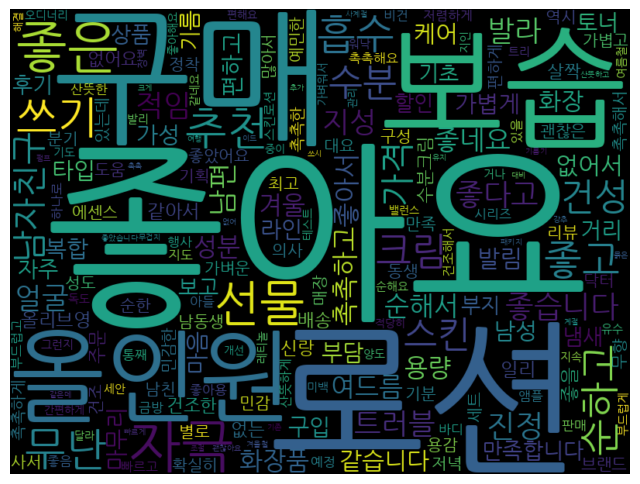

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(font_path=path, background_color='black', width=800, height=600)
cloud = wc.generate_from_frequencies(word_count)

# WordCloud 시각화
plt.figure(figsize=(8,8))
plt.imshow(cloud, interpolation='bilinear')
plt.axis('off')
plt.show()

로션 카테고리에 있는 화장품 특징 (단어 빈도수로)

- 효과 : 보습, 토너, 수분, 앰플, 진정,
- 제형 : 가볍다, 부드럽고, 순하고, 촉촉하고,
- 향 : 산뜻한, 무향, 냄새
- 성분 : 레티놀, 성분, 비건
- 타입 : 지성, 건성, 민감, 복합
- 성벌&나이 : 남자친구, 남편, 남동생, 남성
- 부분 : 여드름, 트러블, 기름
- 계절 : 여름철, 겨울
-
-


#CountVectorizer

In [ ]:
corpus = df['review'].tolist()

In [ ]:
#추가할 불용어 여기에 입력
add_stopwords = '올인원'

for word in add_stopwords.split(','):
    stop_words.append(word)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

cvect = CountVectorizer(ngram_range=(2,4),min_df=0.05, max_df=0.90, stop_words = stop_words)
dtm = cvect.fit_transform(corpus)
vocab = cvect.get_feature_names_out()

df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['귀차', '되어야', '로션', '말해', '스킨', '싶다', '싶어', '싶은', '않는다', '않았다', '올리브영', '있었다', '좋습니다', '좋아요', '화장품'] not in stop_words.
  warnings.warn(


,4계절 내내,가격 대비,가격도 저렴하고,가격도 저렴해서,가격도 좋고,가격도 착하고,가격에 비해,가벼운 로션,가벼운 제형이라,가벼워서 여름에,...,흡수가 빨라,흡수가 빨라서,흡수가 잘되고,흡수가 잘되서,흡수도 빠르고,흡수도 빨라서,흡수도 잘되고,흡수도 좋아요,흡수력도 좋고,흡수력이 좋아서
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
63,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
64,0,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
65,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [ ]:
df_dtm.sum().to_frame()

,0
4계절 내내,5
가격 대비,5
가격도 저렴하고,10
가격도 저렴해서,4
가격도 좋고,5
...,...
흡수도 빨라서,9
흡수도 잘되고,8
흡수도 좋아요,4
흡수력도 좋고,9


In [ ]:
df_dtm.sum().to_frame().sort_values(by=0, axis=0, ascending=False).head(50)


,0
자극없이 순하고,83
쓰기 좋아요,73
자극 없이,59
쓰기 좋은,56
좋다고 하네요,48
끈적임 없이,46
사용하기 좋아요,46
향도 좋고,38
사용하기 좋은,38
여름에 쓰기,37


In [ ]:
df_dtm.sum().to_frame().sort_values(by=0, axis=0, ascending=False).tail(50)

,0
편하고 좋습니다,4
편하다고 하네요,4
피부가 엄청,4
피부가 예민해져서,4
남편이 쓰는,4
냄새도 좋고,4
너무너무 좋아요,4
눈에 띄게,4
느낌이 들어요,4
느낌이 좋습니다,4


TF-IDF 가중치

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tvect = TfidfVectorizer(ngram_range=(2,5),min_df=0.05, max_df=0.90, stop_words = stop_words)
dtm = tvect.fit_transform(corpus)
dtm

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:408: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['귀차', '되어야', '로션', '말해', '스킨', '싶다', '싶어', '싶은', '않는다', '않았다', '올리브영', '있었다', '좋습니다', '좋아요', '화장품'] not in stop_words.
  warnings.warn(


<67x786 sparse matrix of type '<class 'numpy.float64'>'
	with 5164 stored elements in Compressed Sparse Row format>

In [ ]:
dtm.toarray()

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.09083689, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.11863526, 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.14735099, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.0973508 , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]])

In [ ]:
vocab = tvect.get_feature_names_out()
vocab

array(['4계절 내내', '가격 대비', '가격도 저렴하고', '가격도 저렴해서', '가격도 좋고', '가격도 착하고',
       '가격에 비해', '가벼운 로션', '가벼운 제형이라', '가벼워서 여름에', '가볍게 바르고', '가볍게 바르기',
       '가볍게 바르기 좋아요', '가볍게 바르기 좋은', '가볍게 바를', '가볍게 발려서', '가볍게 발려요',
       '가볍게 발리고', '가볍게 발리는데', '가볍게 사용하기', '가볍게 쓰기', '가볍게 쓰기 좋은',
       '가볍고 끈적이지', '가볍고 좋아요', '가성비 좋게', '가성비 좋아서', '가성비 좋아요', '가성비 좋은',
       '가성비가 좋은', '가성비도 좋고', '가을 겨울에', '간편하게 바르기', '간편하게 사용하기',
       '간편하게 사용할', '간편하고 좋아요', '감사합니다 남편이', '감사합니다 재구매', '강하지 않아',
       '강하지 않아서', '같아서 좋아요', '거부감 없이', '건성 피부에', '건성에 좋고', '건성에 좋은',
       '건조하신 분들은', '건조한 느낌이', '건조한 피부에', '겉도는 없이', '겨울에 사용하기', '겨울에 쓰기',
       '겨울에 쓰기에는', '겨울에 쓰면', '겨울철에 사용하기', '경우가 많은데', '계절 상관없이',
       '괜찮다고 하네요', '구매 했습니다', '구매하게 되었습니다', '구매하게 되었어요', '구매한 제품입니다',
       '구매할 예정입니다', '구매해봤어요 기대', '구매해봤어요 기대 생각보다', '구매해봤어요 기대 생각보다 좋네효',
       '구매해봤어요 기대 생각보다 좋네효 재구매', '구매해서 사용하고', '구매해서 사용하는데', '구매해서 좋아요',
       '구매했는데 생각보다', '구매했는데 촉촉하고', '구성도 좋고', '기대 생각보다', '기대 생각보다 좋네효',
       '기대 생각보다 좋네효 재구매', '기

In [ ]:
df_dtm = pd.DataFrame(dtm.toarray(), columns=vocab)
df_dtm

,4계절 내내,가격 대비,가격도 저렴하고,가격도 저렴해서,가격도 좋고,가격도 착하고,가격에 비해,가벼운 로션,가벼운 제형이라,가벼워서 여름에,...,흡수가 빨라,흡수가 빨라서,흡수가 잘되고,흡수가 잘되서,흡수도 빠르고,흡수도 빨라서,흡수도 잘되고,흡수도 좋아요,흡수력도 좋고,흡수력이 좋아서
0,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.098313,0.0,0.000000,0.0,0.0
1,0.0,0.000000,0.090837,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
2,0.0,0.118635,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
3,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.101039,0.000000,0.000000,0.0,0.000000,0.0,0.0
4,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.092044,0.0,0.000000,0.000000,0.000000,0.0,0.105821,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
63,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.108686,0.124954,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
64,0.0,0.147351,0.000000,0.0,0.147351,0.000000,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0
65,0.0,0.000000,0.097351,0.0,0.000000,0.110411,0.0,0.0,0.000000,0.000000,...,0.0,0.000000,0.0,0.000000,0.093957,0.000000,0.0,0.000000,0.0,0.0


In [ ]:
df_dtm.sum().to_frame()

,0
4계절 내내,0.587441
가격 대비,0.597271
가격도 저렴하고,0.915523
가격도 저렴해서,0.428718
가격도 좋고,0.581107
...,...
흡수도 빨라서,0.800425
흡수도 잘되고,0.789731
흡수도 좋아요,0.435347
흡수력도 좋고,0.808281


In [ ]:
df_dtm.sum().to_frame().sort_values(by=0, axis=0, ascending=False).head(50)

,0
자극없이 순하고,3.752106
쓰기 좋아요,3.399673
쓰기 좋은,3.031661
자극 없이,3.002683
좋다고 하네요,2.846521
사용하기 좋아요,2.553637
향도 좋고,2.518869
않아서 좋아요,2.342434
끈적임 없이,2.335575
무난하게 사용하기,2.331729


In [ ]:
display(df_dtm.style.background_gradient())

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
idf = tvect.idf_
idf

array([3.61006979, 3.42774824, 3.02228313, 3.61006979, 3.42774824,
       3.42774824, 3.61006979, 3.42774824, 3.14006616, 3.61006979,
       3.61006979, 2.12846525, 2.82161243, 3.27359756, 3.27359756,
       3.27359756, 3.61006979, 3.61006979, 3.61006979, 3.14006616,
       2.38629436, 3.27359756, 3.61006979, 3.61006979, 3.61006979,
       3.61006979, 3.42774824, 2.91692261, 3.42774824, 3.02228313,
       3.61006979, 3.61006979, 3.27359756, 3.42774824, 3.61006979,
       3.61006979, 3.61006979, 3.27359756, 3.14006616, 3.61006979,
       3.61006979, 2.82161243, 3.42774824, 3.61006979, 3.61006979,
       3.27359756, 2.82161243, 3.42774824, 3.61006979, 3.14006616,
       3.42774824, 3.42774824, 3.61006979, 3.61006979, 3.61006979,
       3.02228313, 3.42774824, 3.61006979, 3.27359756, 3.61006979,
       3.42774824, 3.42774824, 3.42774824, 3.42774824, 3.42774824,
       3.61006979, 3.61006979, 3.27359756, 3.27359756, 3.42774824,
       3.42774824, 3.42774824, 3.42774824, 3.42774824, 3.42774

In [ ]:
vocab = tvect.get_feature_names_out()

vocab_dict = dict(zip(vocab, idf))

In [ ]:
vocab_list = list(vocab_dict.keys())

In [ ]:
len(vocab_list)

786

In [ ]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 60.0 MB/s eta 0:00:00


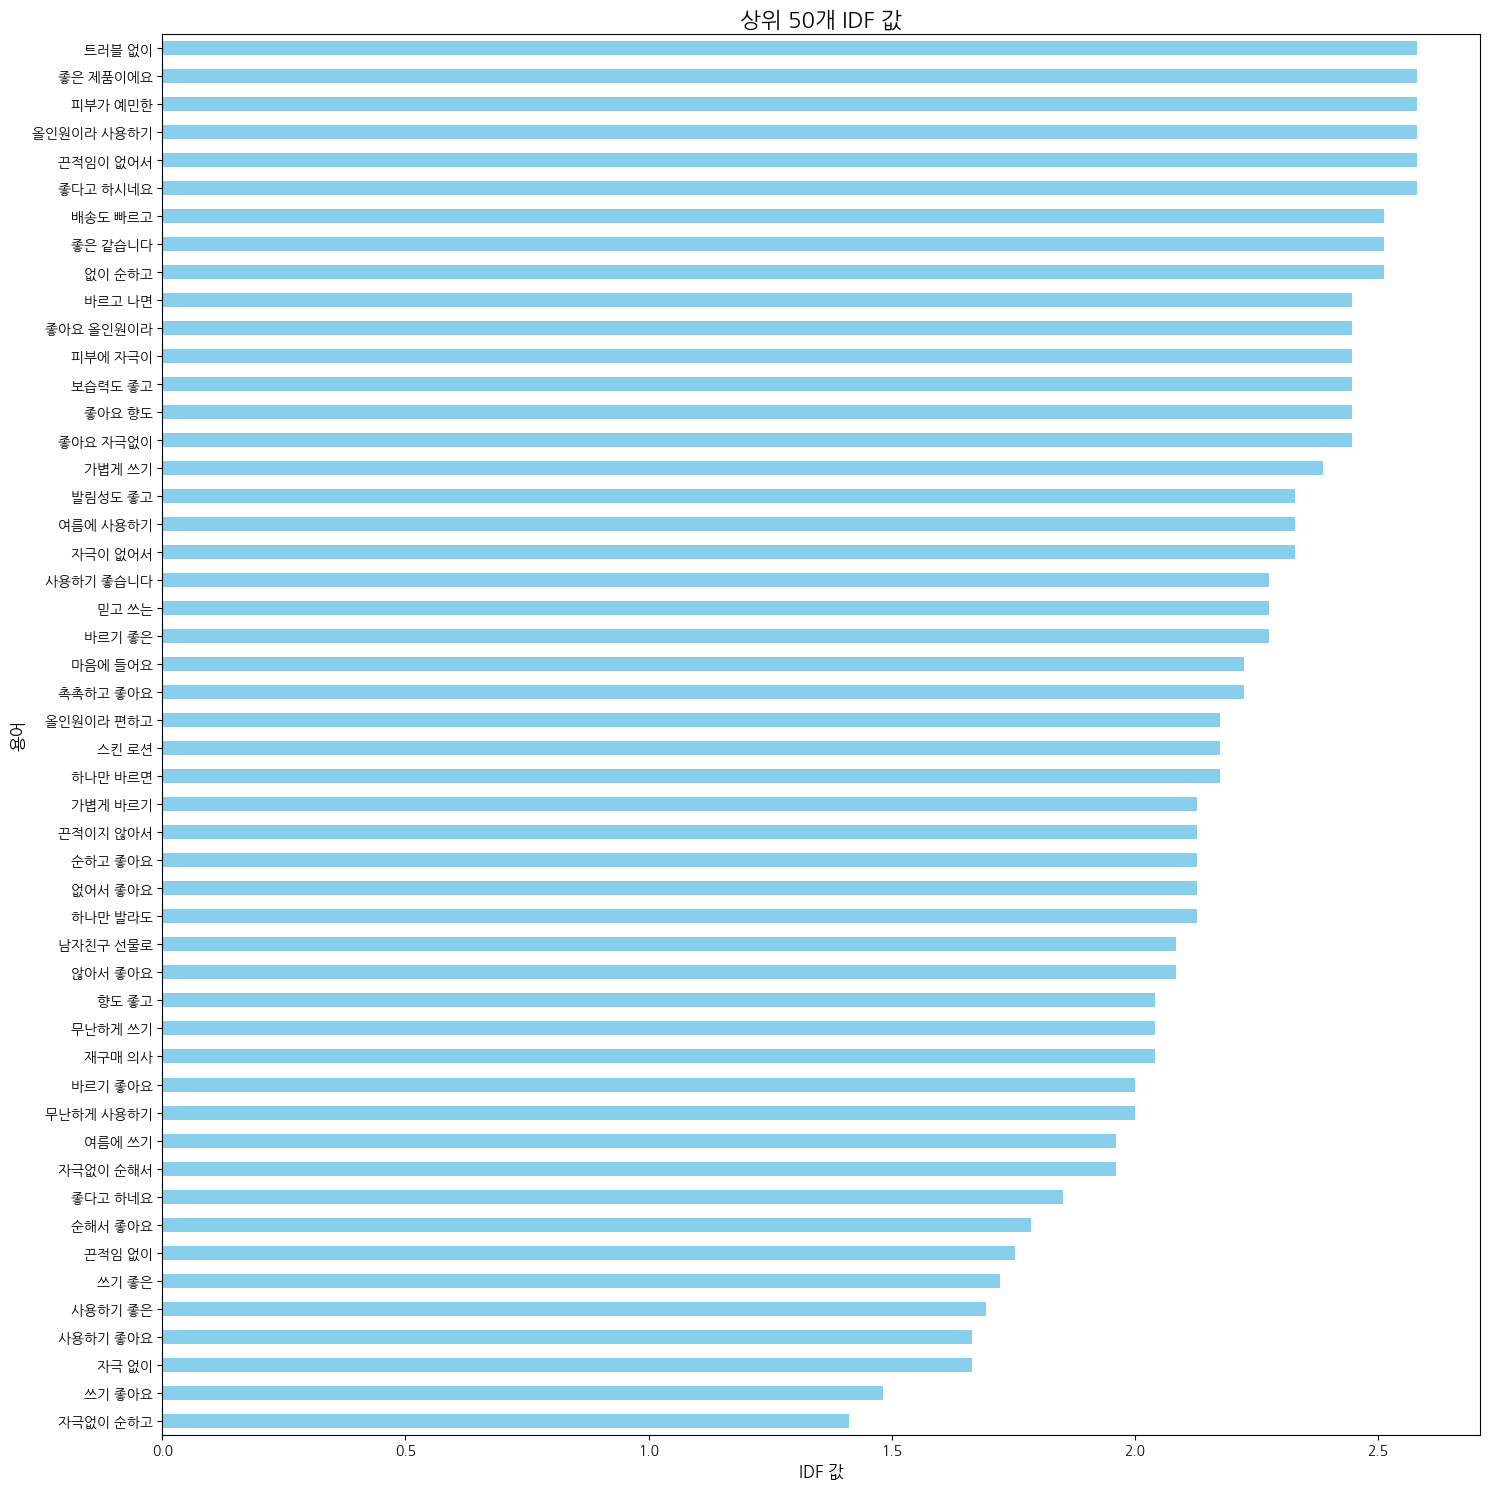

In [ ]:
import koreanize_matplotlib

idf_dict = dict(zip(vocab, idf))

pd.Series(idf_dict)

idf_series = pd.Series(idf_dict).sort_values(ascending=True).head(50)

# 수평 막대 그래프 그리기
plt.figure(figsize=(15, 15))
idf_series.plot(kind='barh', color='skyblue')

# 레이블 및 제목 추가
plt.xlabel('IDF 값', fontsize=12)
plt.ylabel('용어', fontsize=12)
plt.title('상위 50개 IDF 값', fontsize=16)

# 그래프 표시
plt.tight_layout()
plt.show()

로션 카테고리에 있는 화장품 특징 (단어 빈도수로)

- 효과 : 보습, 토너, 수분, 앰플, 진정,
- 제형 : 가볍다, 부드럽고, 순하고, 촉촉하고,
- 향 : 산뜻한, 무향, 냄새
- 성분 : 레티놀, 성분, 비건
- 타입 : 지성, 건성, 민감, 복합
- 성벌&나이 : 남자친구, 남편, 남동생, 남성
- 부분 : 여드름, 트러블, 기름
- 계절 : 여름철, 겨울

In [ ]:
from collections import defaultdict


# 분류할 카테고리(지정해줘야함)
categories = {
    '효과': ['효과', '효능', '결과', '진정','보습','수분','앰플','토너'],
    '제형': ['제형', '질감', '텍스처', '로션', '크림','가볍','부드럽고','순하고','촉촉','가벼워서'],
    '향': ['향', '향기', '냄새','산','산뜻한','무향'],
    '가격': ['가격', '비용', '가성비', '저렴'],
    '지속력': ['지속력', '오래', '지속', '스며들다'],
    '사용감': ['사용감', '느낌', '발림성', '무난','부드럽고','순하고','흡수',],
    '성분': ['성분', '재료', '원료', '자극','레티놀','비건'],
    '피부타입': ['피부타입', '피부', '건성', '지성', '민감성', '복합성'],
    '성별': ['성별', '남성', '여성', '남자', '여자','남편','남자친구','아들'],
    '나이대': ['나이대', '연령', '나이'],
    '평가': ['평가', '리뷰', '후기', '추천', '만족', '재구매','추천'],
    '계절' : ['여름철','겨울'],
    '부위' : ['여드름','트러블','기름']
}

# 단어 분류
classified_terms = defaultdict(list)

for term in vocab_list:
    for category, keywords in categories.items():
        if any(keyword in term for keyword in keywords):
            classified_terms[category].append(term)

# 결과 출력
for category, words in classified_terms.items():
    print(f"{category}: {words}")


가격: ['가격 대비', '가격도 저렴하고', '가격도 저렴해서', '가격도 좋고', '가격도 착하고', '가격에 비해', '가성비 좋게', '가성비 좋아서', '가성비 좋아요', '가성비 좋은', '가성비가 좋은', '가성비도 좋고', '비해 가격이', '저렴하게 구매해서', '저렴하게 구매했어요', '저렴하게 사서', '저렴한 가격에', '저렴한 가격으로', '좋고 가격도', '좋은 가격에', '착한 가격에', '합리적인 가격에']
제형: ['가벼운 로션', '가벼운 제형이라', '가벼워서 여름에', '가볍게 바르고', '가볍게 바르기', '가볍게 바르기 좋아요', '가볍게 바르기 좋은', '가볍게 바를', '가볍게 발려서', '가볍게 발려요', '가볍게 발리고', '가볍게 발리는데', '가볍게 사용하기', '가볍게 쓰기', '가볍게 쓰기 좋은', '가볍고 끈적이지', '가볍고 좋아요', '구매했는데 촉촉하고', '로션 따로', '로션 바르고', '로션 바르기', '로션 찾다가', '로션 크림', '로션으로 샀는데', '로션을 찾고', '로션이 필요해서', '묽은 제형이라', '발림성도 부드럽고', '사용하는 로션', '성분도 순하고', '순하고 발림성', '순하고 발림성도', '순하고 보습도', '순하고 보습력도', '순하고 보습력이', '순하고 보습에', '순하고 보습에도', '순하고 보습이', '순하고 자극없이', '순하고 자극이', '순하고 자극이 없어서', '순하고 자극이 없어요', '순하고 좋다고', '순하고 좋아요', '순하고 촉촉하고', '순하고 촉촉해서', '순하고 촉촉해요', '순하고 피부에', '순하고 향도', '순하고 흡수도', '순한 로션', '스킨 로션', '스킨 로션 따로', '스킨 로션을', '쓰고 크림', '엄청 순하고', '엄청 촉촉하고', '없이 순하고', '없이 촉촉하게', '여름에 가볍게', '여름에 가볍게 쓰기', '여름에 크림', '자극 없이 순하고', '자극도 순하고', '자극없이 순하고', '자극없이 순하고 보습

In [ ]:
import pandas as pd
from collections import defaultdict

categories = {
    '효과': ['효과', '효능', '결과', '진정','보습','수분','앰플','토너'],
    '제형': ['제형', '질감', '텍스처', '로션', '크림','가볍','부드럽고','촉촉','가벼워서'],
    '향': ['향', '향기', '냄새','산','산뜻한','무향'],
    '가격': ['가격', '비용', '가성비', '저렴'],
    '지속력': ['지속력', '오래', '지속', '스며들다'],
    '사용감': ['사용감', '느낌', '발림성', '무난','부드럽고','순하고','흡수','자극'],
    '성분': ['성분', '재료', '원료','레티놀','비건'],
    '피부타입': ['피부타입', '피부', '건성', '지성', '민감성', '복합성'],
    '성별': ['성별', '남성', '여성', '남자', '여자','남편','남자친구','아들'],
    '나이대': ['나이대', '연령', '나이'],
    '평가': ['평가', '리뷰', '후기', '추천', '만족', '재구매','추천'],
    '계절' : ['여름철','겨울'],
    '부위' : ['여드름','트러블','기름']
}

classified_terms = defaultdict(list)

for term in vocab_list:
    for category, keywords in categories.items():
        if any(keyword in term for keyword in keywords):
            classified_terms[category].append(term)

# 데이터프레임 생성
rows = []
for category, words in classified_terms.items():
    for word in words:
        rows.append({'Category': category, 'Term': word})

Classified_words = pd.DataFrame(rows)

# 결과 출력
Classified_words



,Category,Term
0,가격,가격 대비
1,가격,가격도 저렴하고
2,가격,가격도 저렴해서
3,가격,가격도 좋고
4,가격,가격도 착하고
...,...,...
434,부위,트러블 올라오는
435,부위,트러블 피부에
436,부위,트러블이 나거나
437,부위,피부에 트러블


In [ ]:
Classified_words.groupby('Category').count()

,Term
Category,
가격,22
계절,7
부위,10
사용감,116
성별,23
성분,4
제형,67
지속력,1
평가,45


<Axes: xlabel='Category'>

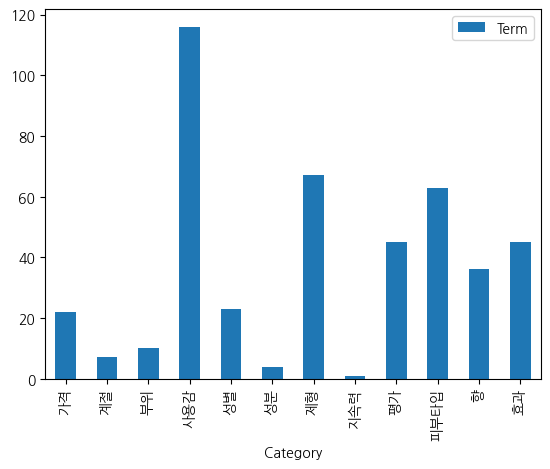

In [ ]:

#가로 막대 그래프로 시각화
Classified_words.groupby('Category').count().plot(kind='bar')

## 제형

- 가볍다. 촉촉하다. 부드럽다. 묽은제형. 순하다

In [ ]:
Classified_words[Classified_words['Category'] == '제형'].tail(50)

,Category,Term
39,제형,구매했는데 촉촉하고
40,제형,로션 따로
41,제형,로션 바르고
42,제형,로션 바르기
43,제형,로션 찾다가
44,제형,로션 크림
45,제형,로션으로 샀는데
46,제형,로션을 찾고
47,제형,로션이 필요해서
48,제형,묽은 제형이라


## 사용감

- 순하고, 발림성이 좋다, 무난하다. 산뜻한 느낌, 시원한 느낌, 흡수력, 자극이 적다

In [ ]:
Classified_words[Classified_words['Category'] == '사용감'].head(50)

,Category,Term
227,사용감,건조한 느낌이
228,사용감,느낌을 받았어요
229,사용감,느낌이 들어서
230,사용감,느낌이 들어요
231,사용감,느낌이 좋습니다
232,사용감,느낌이라 좋아요
233,사용감,무난무난하게 사용하기
234,사용감,무난하게 사용하기
235,사용감,무난하게 사용하기 좋아요
236,사용감,무난하게 사용하기 좋은


## 성분


In [ ]:
Classified_words[Classified_words['Category'] == '성분']

,Category,Term
424,성분,성분도 순하고
425,성분,성분도 좋고
426,성분,성분이 순해서
427,성분,좋고 성분도


## 피부타입

- 수부지, 여드름피부, 예민한 피부, 지성, 건조

In [ ]:
Classified_words[Classified_words['Category'] == '피부타입'].head(60)


,Category,Term
164,피부타입,건성 피부에
165,피부타입,건성에 좋고
166,피부타입,건성에 좋은
167,피부타입,건조한 피부에
168,피부타입,남편 피부에
169,피부타입,모든 피부에
170,피부타입,모든 피부타입이
171,피부타입,민감성 피부인
172,피부타입,민감성 피부인데
173,피부타입,민감한 피부를


## 효과

- 보습, 수분, 진정

In [ ]:
Classified_words[Classified_words['Category'] == '효과'].head(60)

,Category,Term
379,효과,보습 잘되고
380,효과,보습 좋은
381,효과,보습 효과가
382,효과,보습감도 좋아서
383,효과,보습도 잘되고
384,효과,보습도 좋고
385,효과,보습도 좋아서
386,효과,보습도 좋아요
387,효과,보습력 좋고
388,효과,보습력 좋은


## 향

- 무향, 산뜻한, 은은한

In [ ]:
Classified_words[Classified_words['Category'] == '향'].head(60)


,Category,Term
343,향,냄새도 좋고
344,향,무향에 가까워서
345,향,무향에 가깝고
346,향,산뜻하게 마무리
347,향,산뜻한 느낌이
348,향,산뜻해서 좋아요
349,향,선물용으로 산건데
350,향,순하고 향도
351,향,은은한 향이
352,향,재구매 의향


## 가격

- 저렴, 착하다, 가성비, 합리적인

In [ ]:
Classified_words[Classified_words['Category'] == '가격'].head(60)


,Category,Term
0,가격,가격 대비
1,가격,가격도 저렴하고
2,가격,가격도 저렴해서
3,가격,가격도 좋고
4,가격,가격도 착하고
5,가격,가격에 비해
6,가격,가성비 좋게
7,가격,가성비 좋아서
8,가격,가성비 좋아요
9,가격,가성비 좋은


## 성별

- 남성, 남편, 남자친구

In [ ]:
Classified_words[Classified_words['Category'] == '성별'].head(60)


,Category,Term
96,성별,감사합니다 남편이
97,성별,남성 분들이
98,성별,남성 화장품
99,성별,남자가 쓰기
100,성별,남자가 쓰기에
101,성별,남자들이 사용하기에
102,성별,남자친구 사줬는데
103,성별,남자친구 선물로
104,성별,남자친구 선물로 사줬는데
105,성별,남자친구 선물용으로


## 부위

- 여드름, 트러블, 기름

In [ ]:
Classified_words[Classified_words['Category'] == '부위'].head(60)


,Category,Term
428,부위,얼굴에 기름이
429,부위,여드름 피부에
430,부위,여드름 피부인데
431,부위,여드름성 피부에
432,부위,좋아요 여드름
433,부위,트러블 없이
434,부위,트러블 올라오는
435,부위,트러블 피부에
436,부위,트러블이 나거나
437,부위,피부에 트러블
